In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


In [3]:
objs = [
    "HD-139664",
    "HD109085",
    "GJ784-PSF",
    "PSF-5-K0",
    "GSC8056-0482",
    "GSC8491-1194",
    "GSC8894-0426",
    "HIP10679",
    "HIP107947",
    "HIP109901",
    "HIP112312A",
    "HIP112312B",
    "HIP114530",
    "HIP118008",
    "HIP12413",
    "HIP12545",
    "HIP12787B",
    "HIP17695",
    "HIP18859",
    "HIP19335",
    "HIP1993",
    "HIP21547",
    "HIP21632",
    "HIP23309",
    "HIP26990",
    "HIP2729",
    "HIP36627",
    "HIP37766",
    "HIP39896B",
    "HIP41889",
    "HIP50156",
    "HIP56445",
    "HIP6485",
    "HIP77199",
    "HIP9892",
    "HIP9902",
    "SSS1102-34",
    "TWA12",
    "TWA23",
    "TYC5672-0216",
    "G238-44",
]

In [4]:
wid = 80
oversample = 4

nwavels = 20
npoly=4

n_modes = 10
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


# ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))




exposures_single = [

    exposure_from_file(ddir + 'n4qs09akq_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    # exposure_from_file(ddir + 'n4qs10asq_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),

    # exposure_from_file(ddir + 'n918a3veq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]

191.9587 5.4
Version 4.1.1
-147.393


([], [])

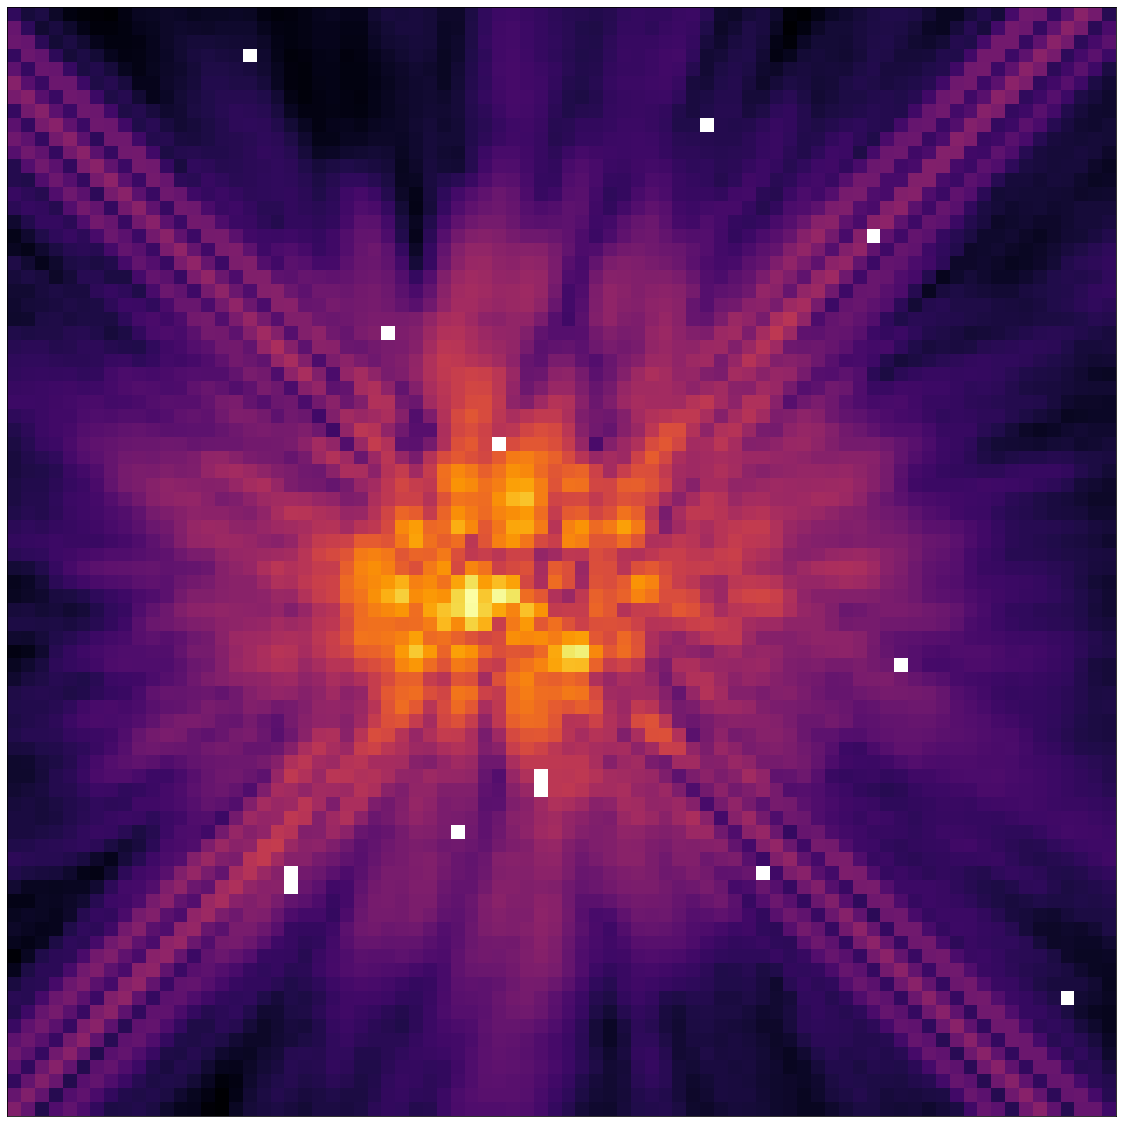

In [6]:
plt.figure(figsize=(20,20))
plt.imshow(exposures_single[0].data**0.125)
plt.xticks([])
plt.yticks([])

In [ ]:
exposures_single[0].target

'HR8799'

In [ ]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(55583.96124985, dtype=float64)

In [ ]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*4)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([0.00807663, -0.01326769])
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,6.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = 0.##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

57.98108072418072


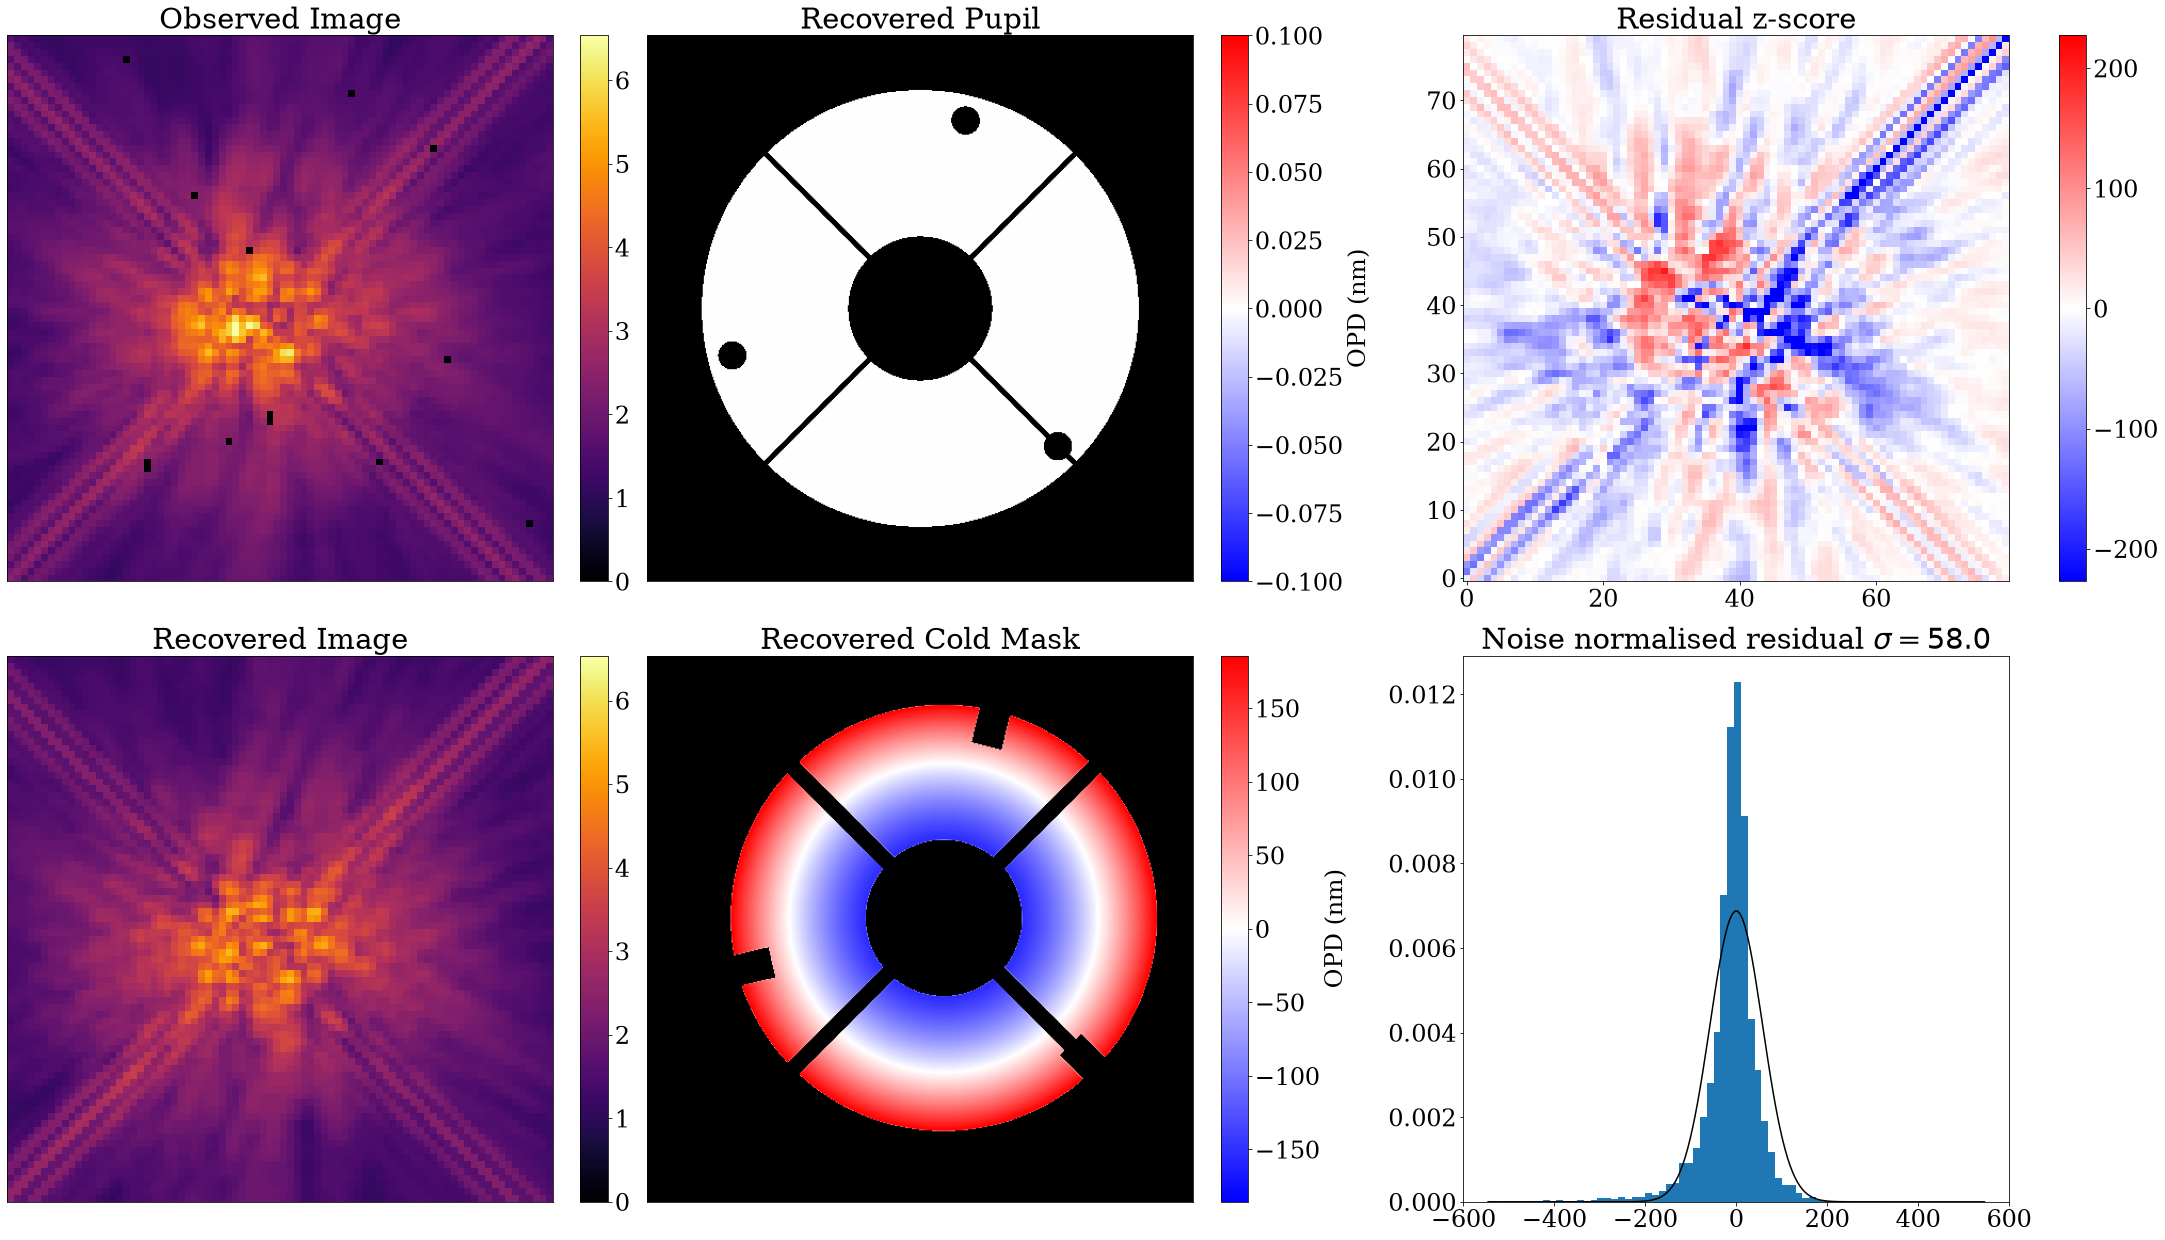

In [ ]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512)

In [178]:
g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*1., 0),
    "spectrum": sgd(g*3, 0),
    "primary_tilt": sgd(g*5, 0),
    "cold_mask_tilt": sgd(g*3, 0),
    "cold_mask_opd": sgd(g*1, 0),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*1, 0),
    "cold_mask_rot": sgd(g*1, 0),
    "primary_rot": sgd(g*1, 0),
    "primary_low": sgd(g*3, 0),
    "occulter_radius": sgd(g*3., 0),
#     "fnumber": sgd(g*2., 0),
}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*0.3, 15.),
    "cold_mask_tilt": sgd(g*3, 0),
    "cold_mask_opd": sgd(g*1, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*5, 70),
    "cold_mask_rot": sgd(g*10, 70),
    "primary_rot": sgd(g*10, 70),

    "primary_low": sgd(g*3, 90),

    # "cold_mask_scale": sgd(g*5, 120),
    # "cold_mask_shear": sgd(g*10, 120),

    # "occulter_radius": sgd(g*0.3, 150),
    # "occulter_coeffs": sgd(g*2, 200),
    # # "fnumber": sgd(g*2., 150),
}

groups = list(things.keys())

In [179]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [180]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 150,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/150 [00:00<?, ?it/s]

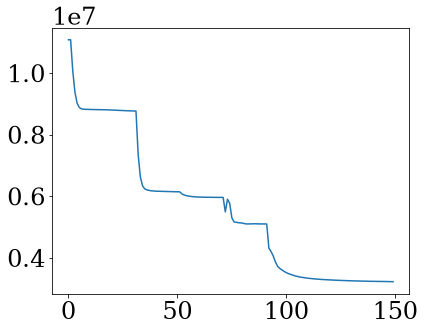

In [181]:
plt.plot(losses[:])

9
31.44105569413938


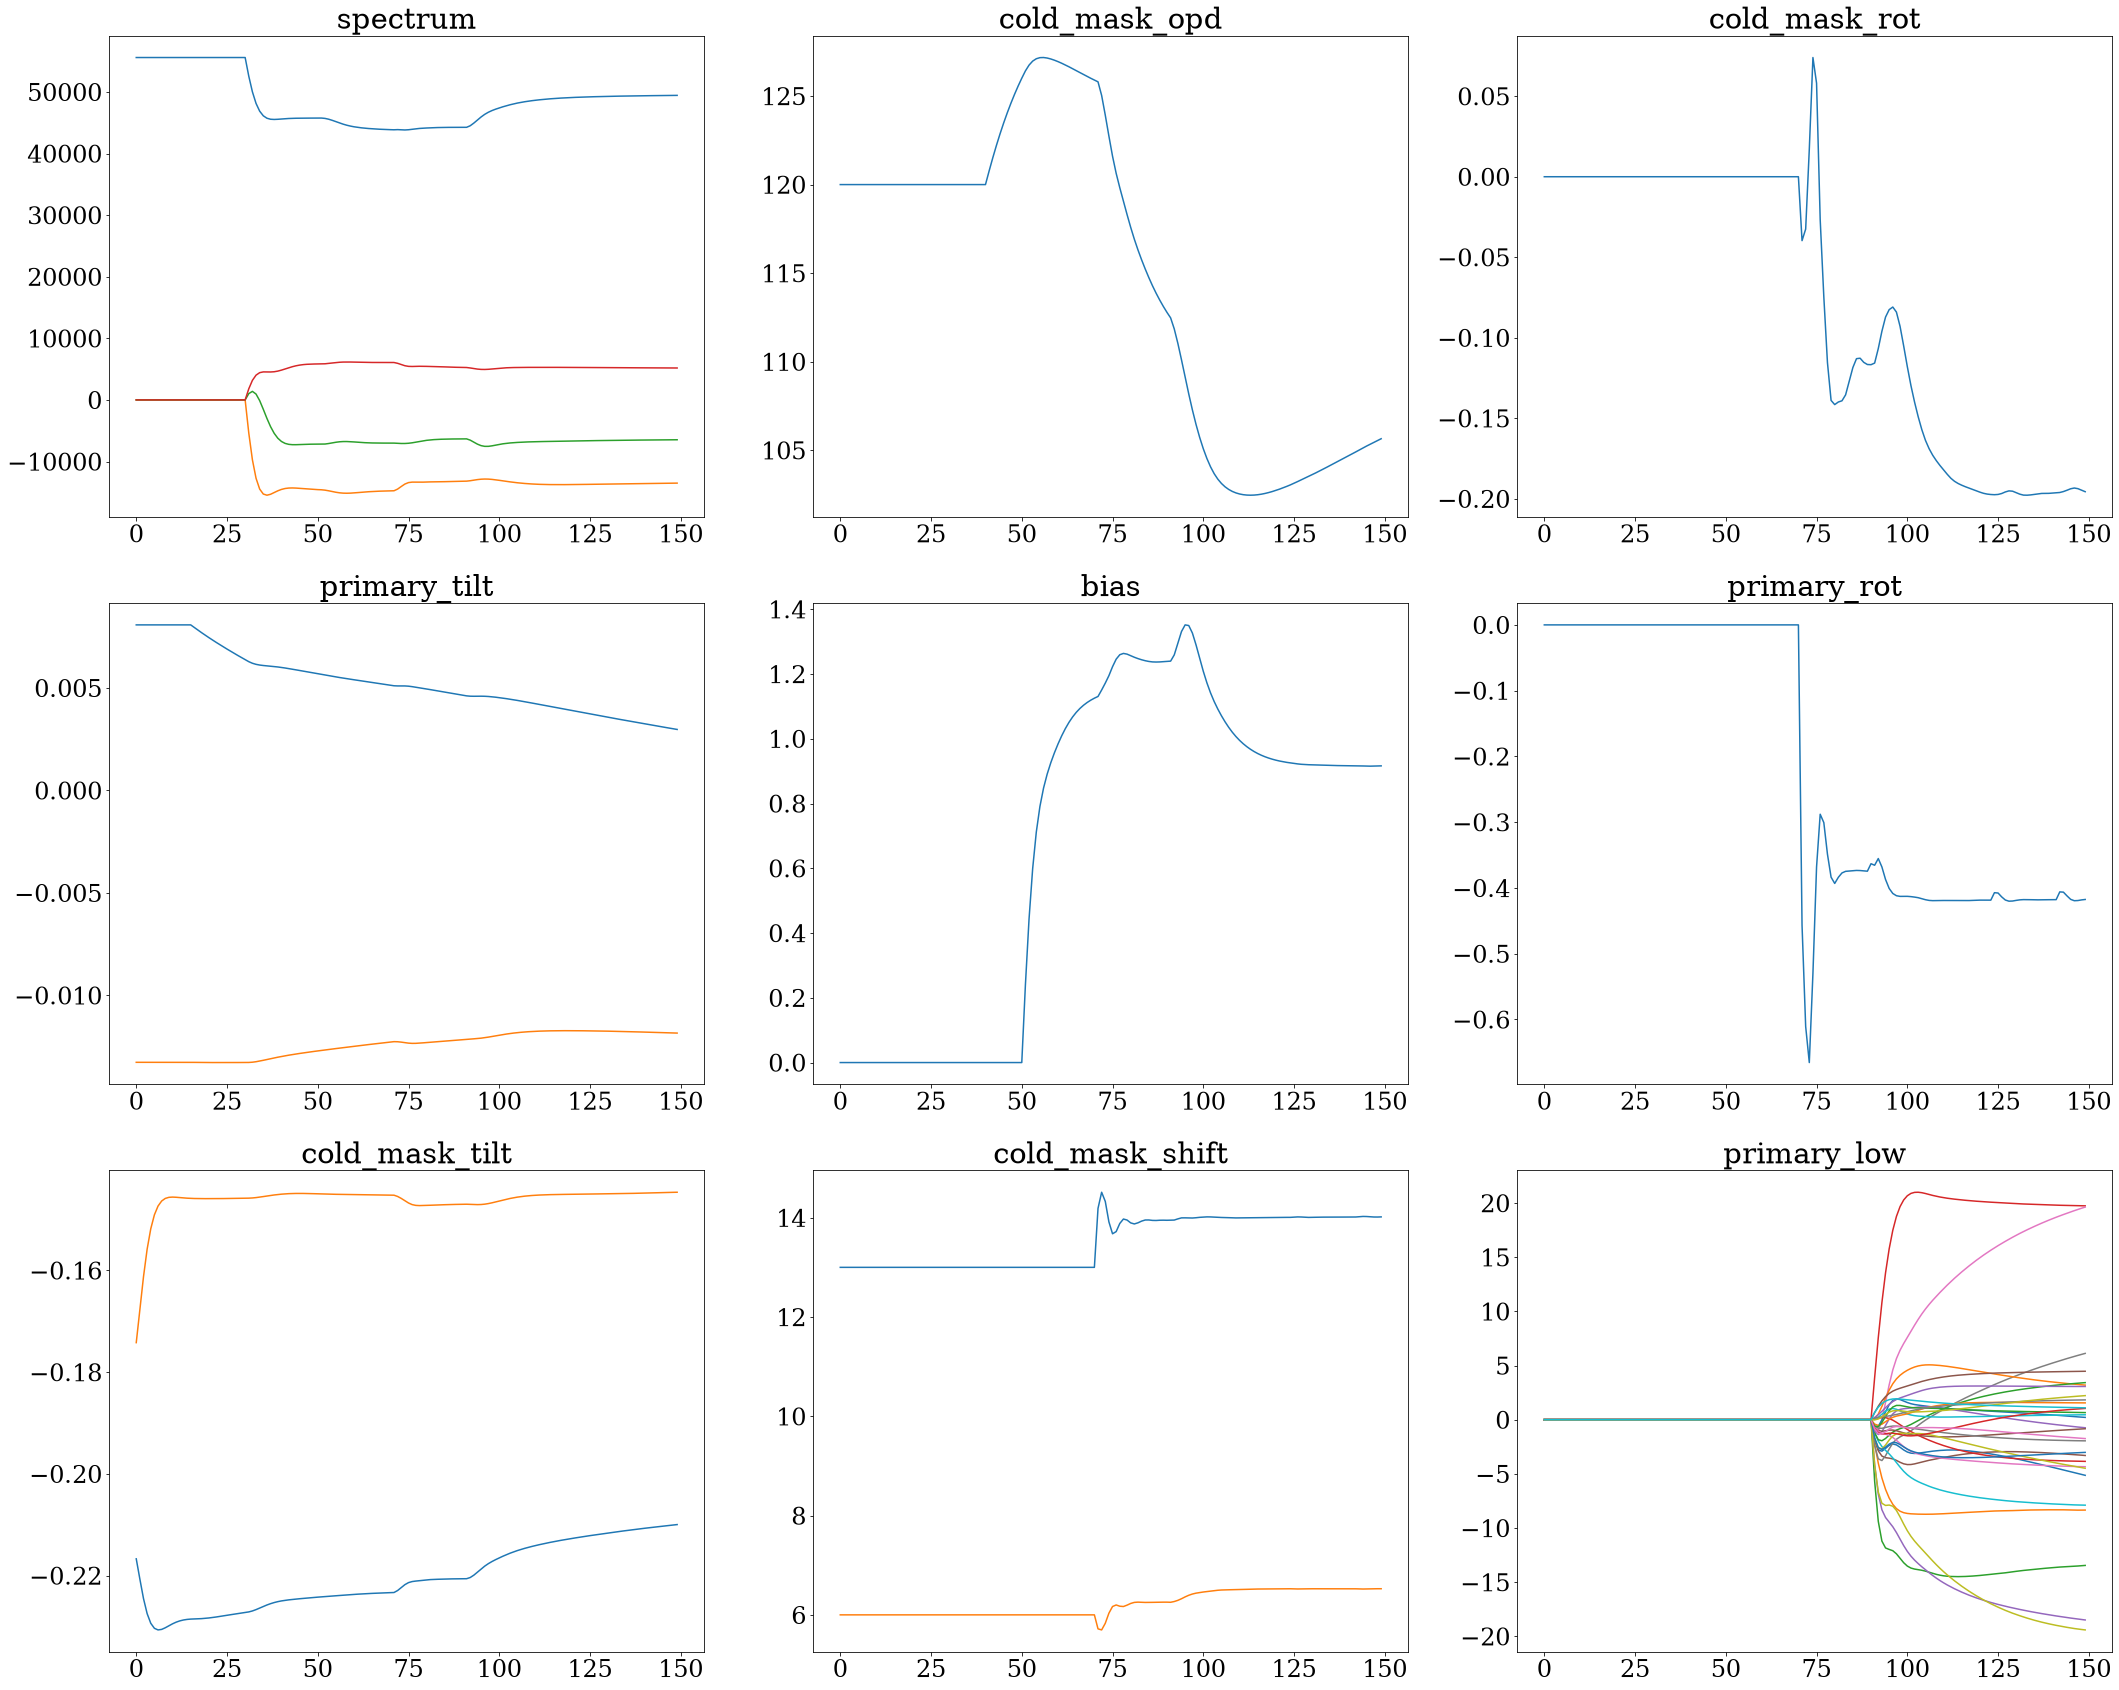

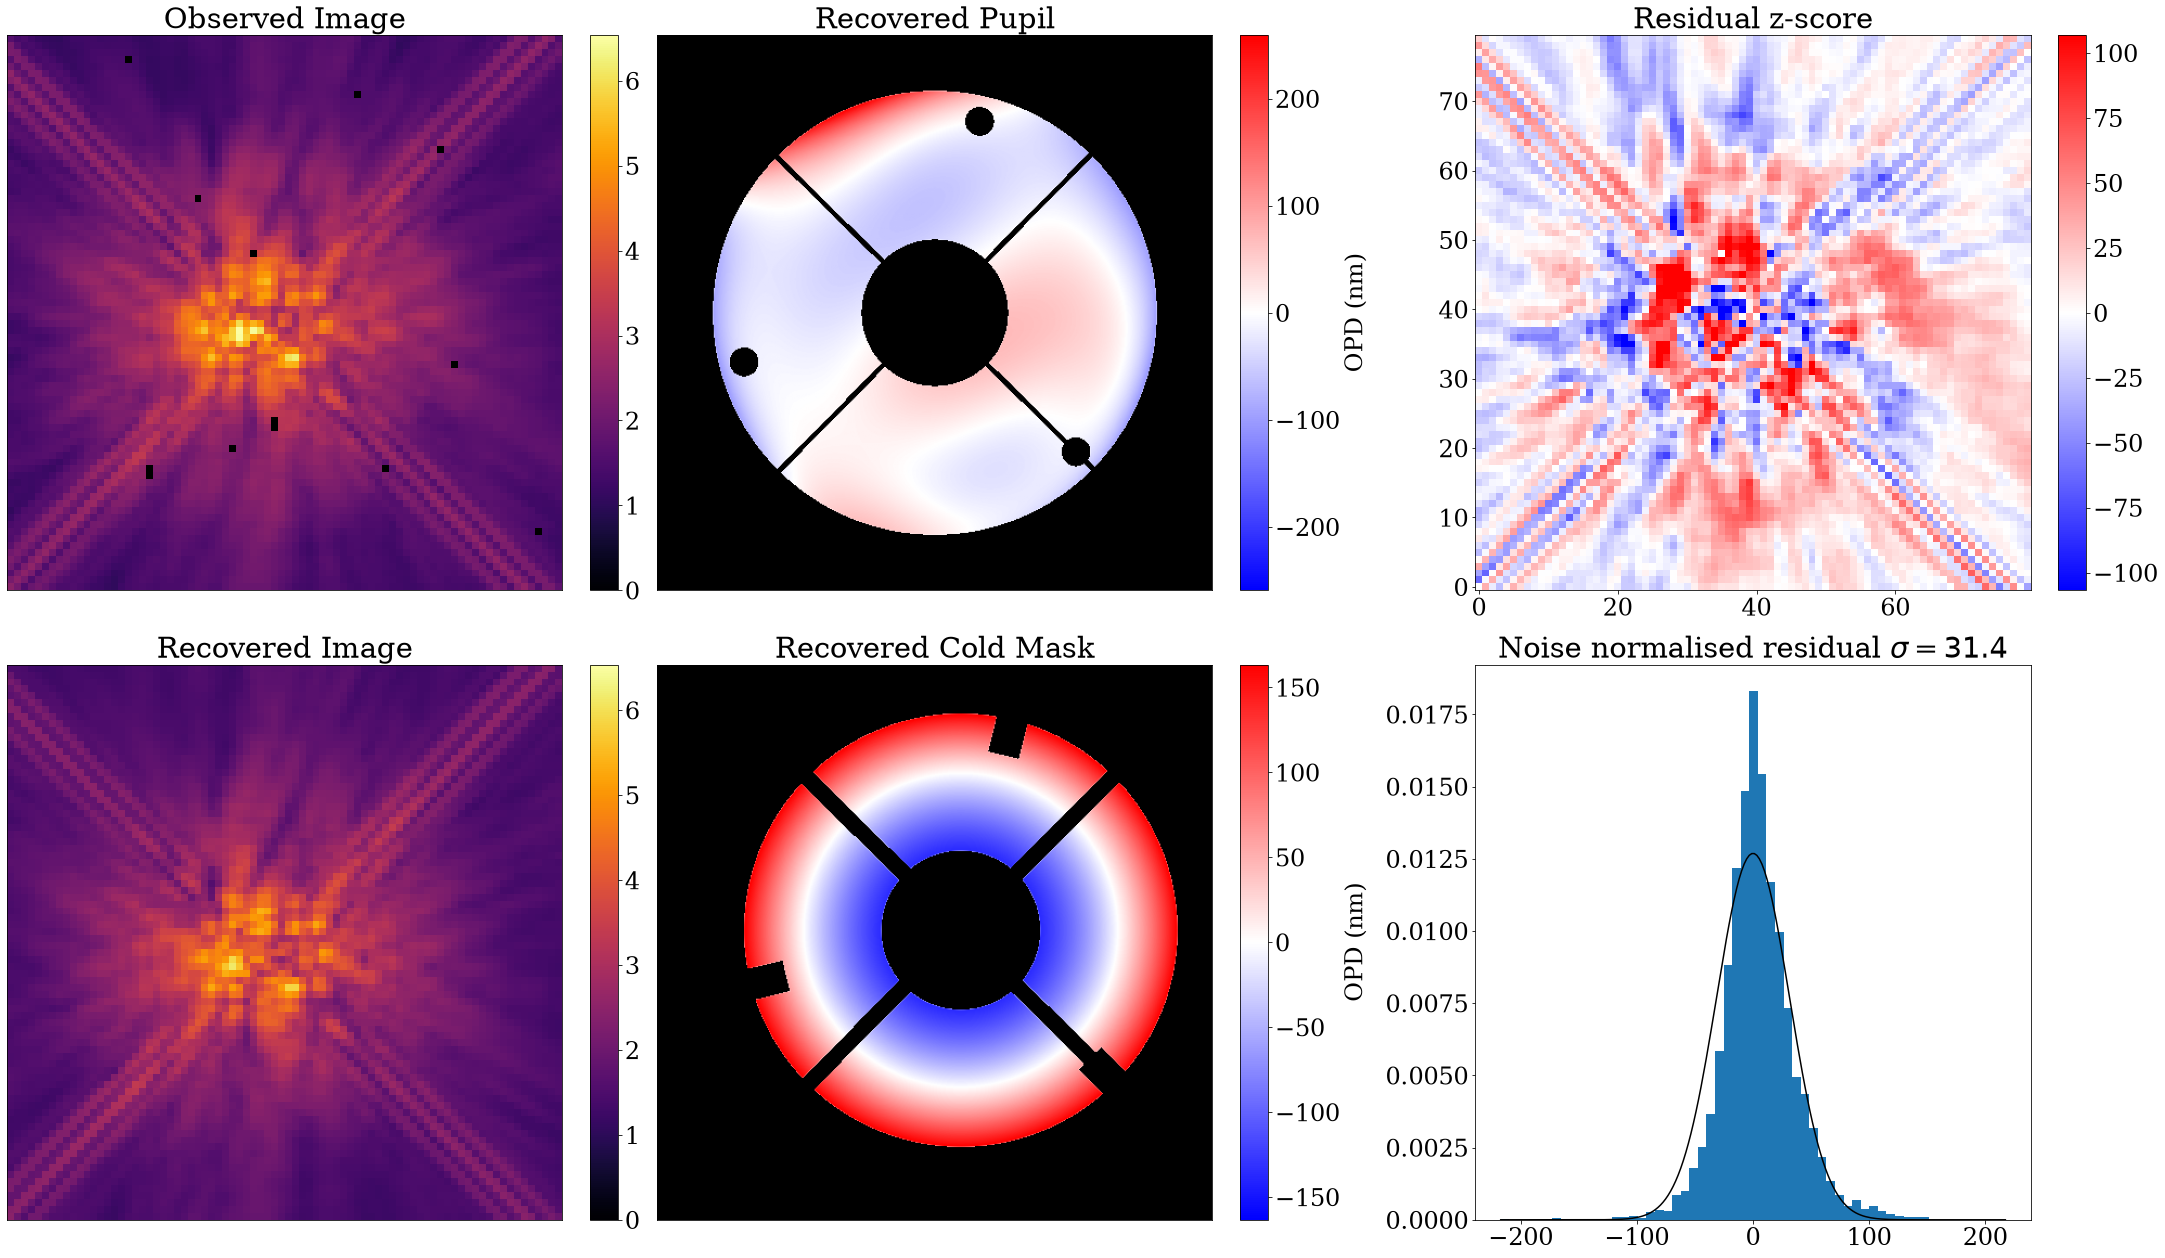

In [182]:
plot_params(params_history, list(things_start.keys()), xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=99, quadrature=False, wf_size=512)

In [183]:
# stop

In [184]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [185]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [186]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [187]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [188]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[1], ss=f64[1], normalise=False)

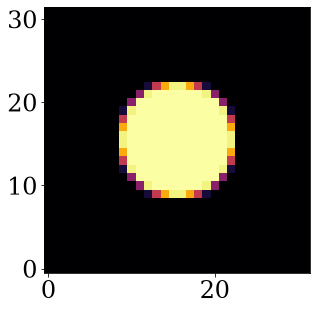

In [189]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=12e-6, npixels=32)).phasor))

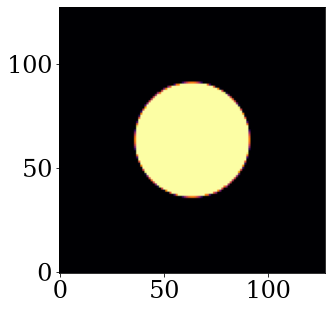

In [190]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [191]:
params_history[-1]

{'bias': {'n4qs09akq': Array(0.91623497, dtype=float64)},
 'cold_mask_opd': {'global': Array([105.65110278], dtype=float64)},
 'cold_mask_rot': {'global': Array(-0.19560046, dtype=float64)},
 'cold_mask_shift': {'global': Array([14.01624844,  6.52630075], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.20997596, -0.14463031], dtype=float64)},
 'primary_low': {'n4qs09akq': Array([ -5.13535221,  -8.34497603, -13.45577076,  19.74730686,
         -18.49240273,  -3.30434831,  19.63220684,   6.12202835,
         -19.41053786,  -7.89178508,   0.21449772,   3.19496355,
           3.42405754,  -3.84708275,  -0.74282368,  -0.83422693,
          -4.34008148,  -1.95221871,  -4.48270292,   0.45428387,
          -3.01746914,   1.55285837,   0.65695874,   1.03988912,
           3.06776487,   4.47248746,  -1.74143964,   1.82898597,
           2.22227195,   1.09714852], dtype=float64)},
 'primary_rot': {'global': Array(-0.41749944, dtype=float64)},
 'primary_tilt': {'n4qs09akq': Array([ 0.0029

In [192]:
# Keep the stage-1 values of parameters that stage 2 does not fit (stage 2 injects into model_single)
model_single = ModelParams(params_history[-1]).inject(model_single)
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [193]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 600,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

  0%|          | 0/600 [00:00<?, ?it/s]

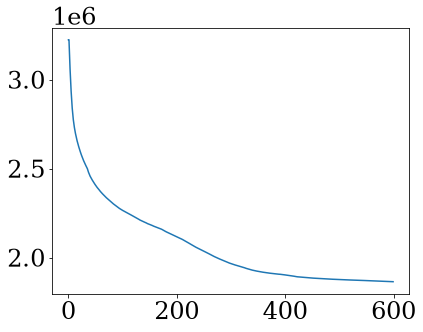

In [194]:
plt.plot(losses[:])

In [195]:
losses[-1]

Array(1864054.20745545, dtype=float64)

11
24.016963803963076


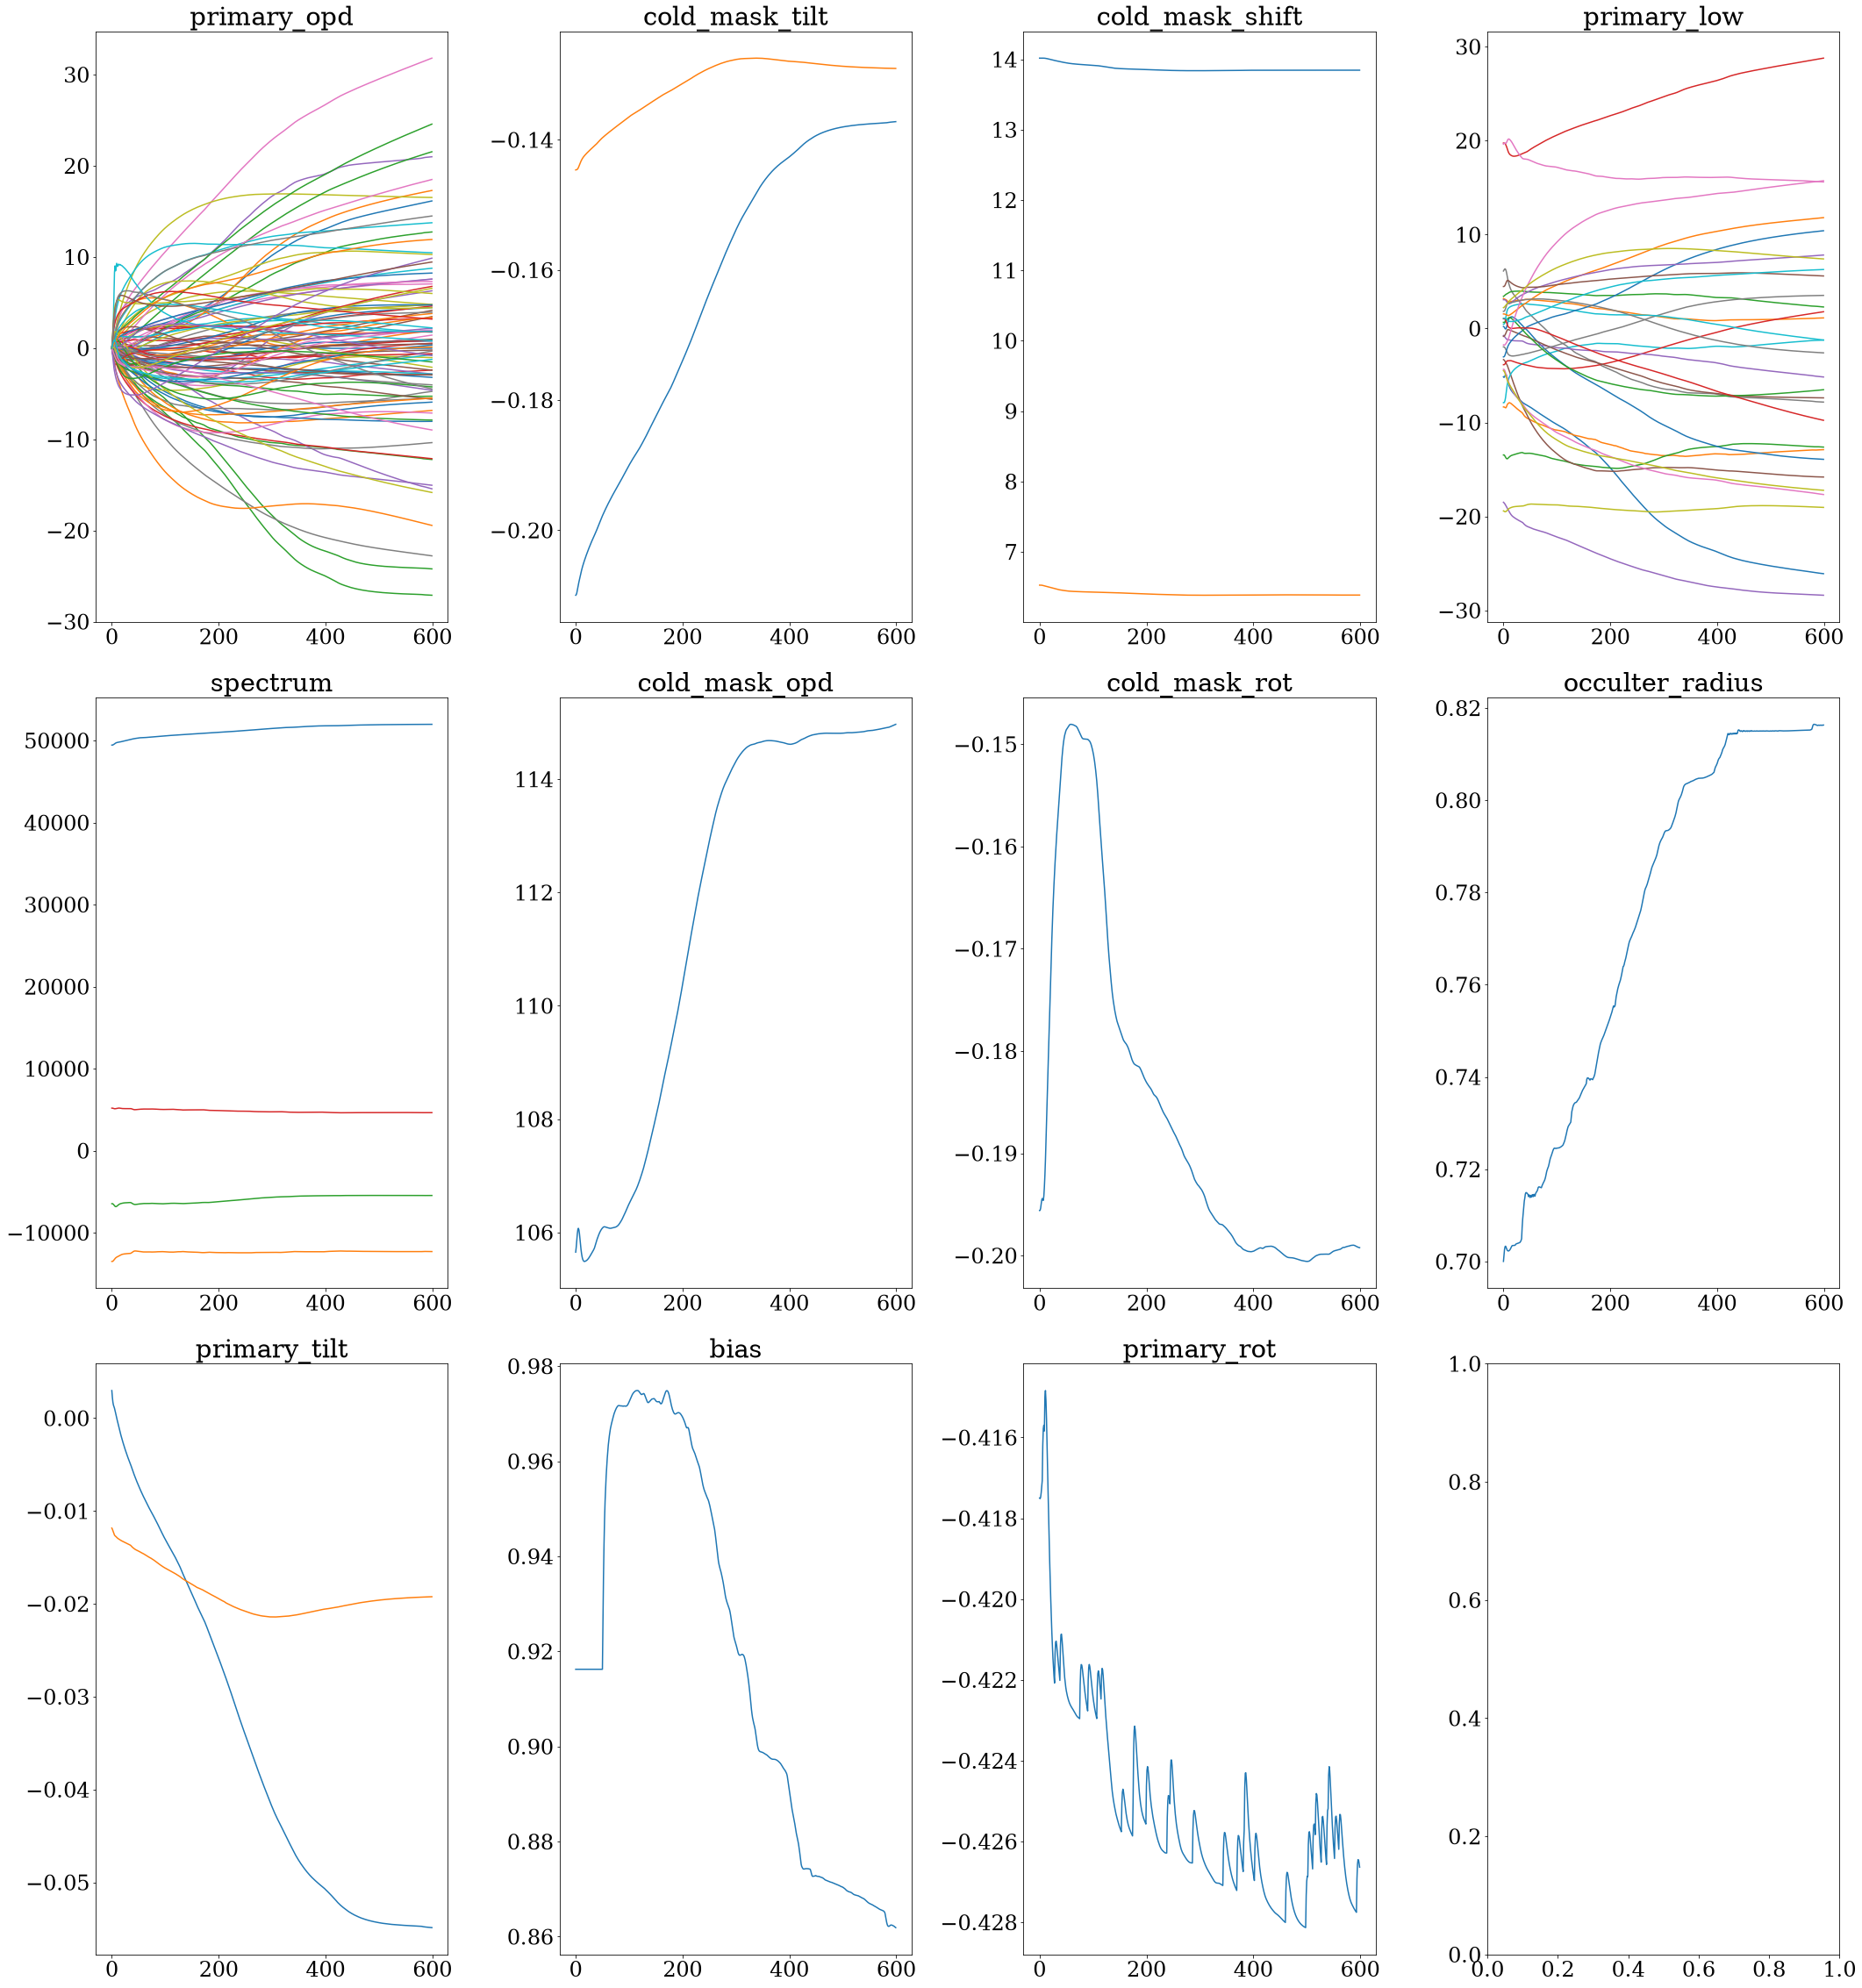

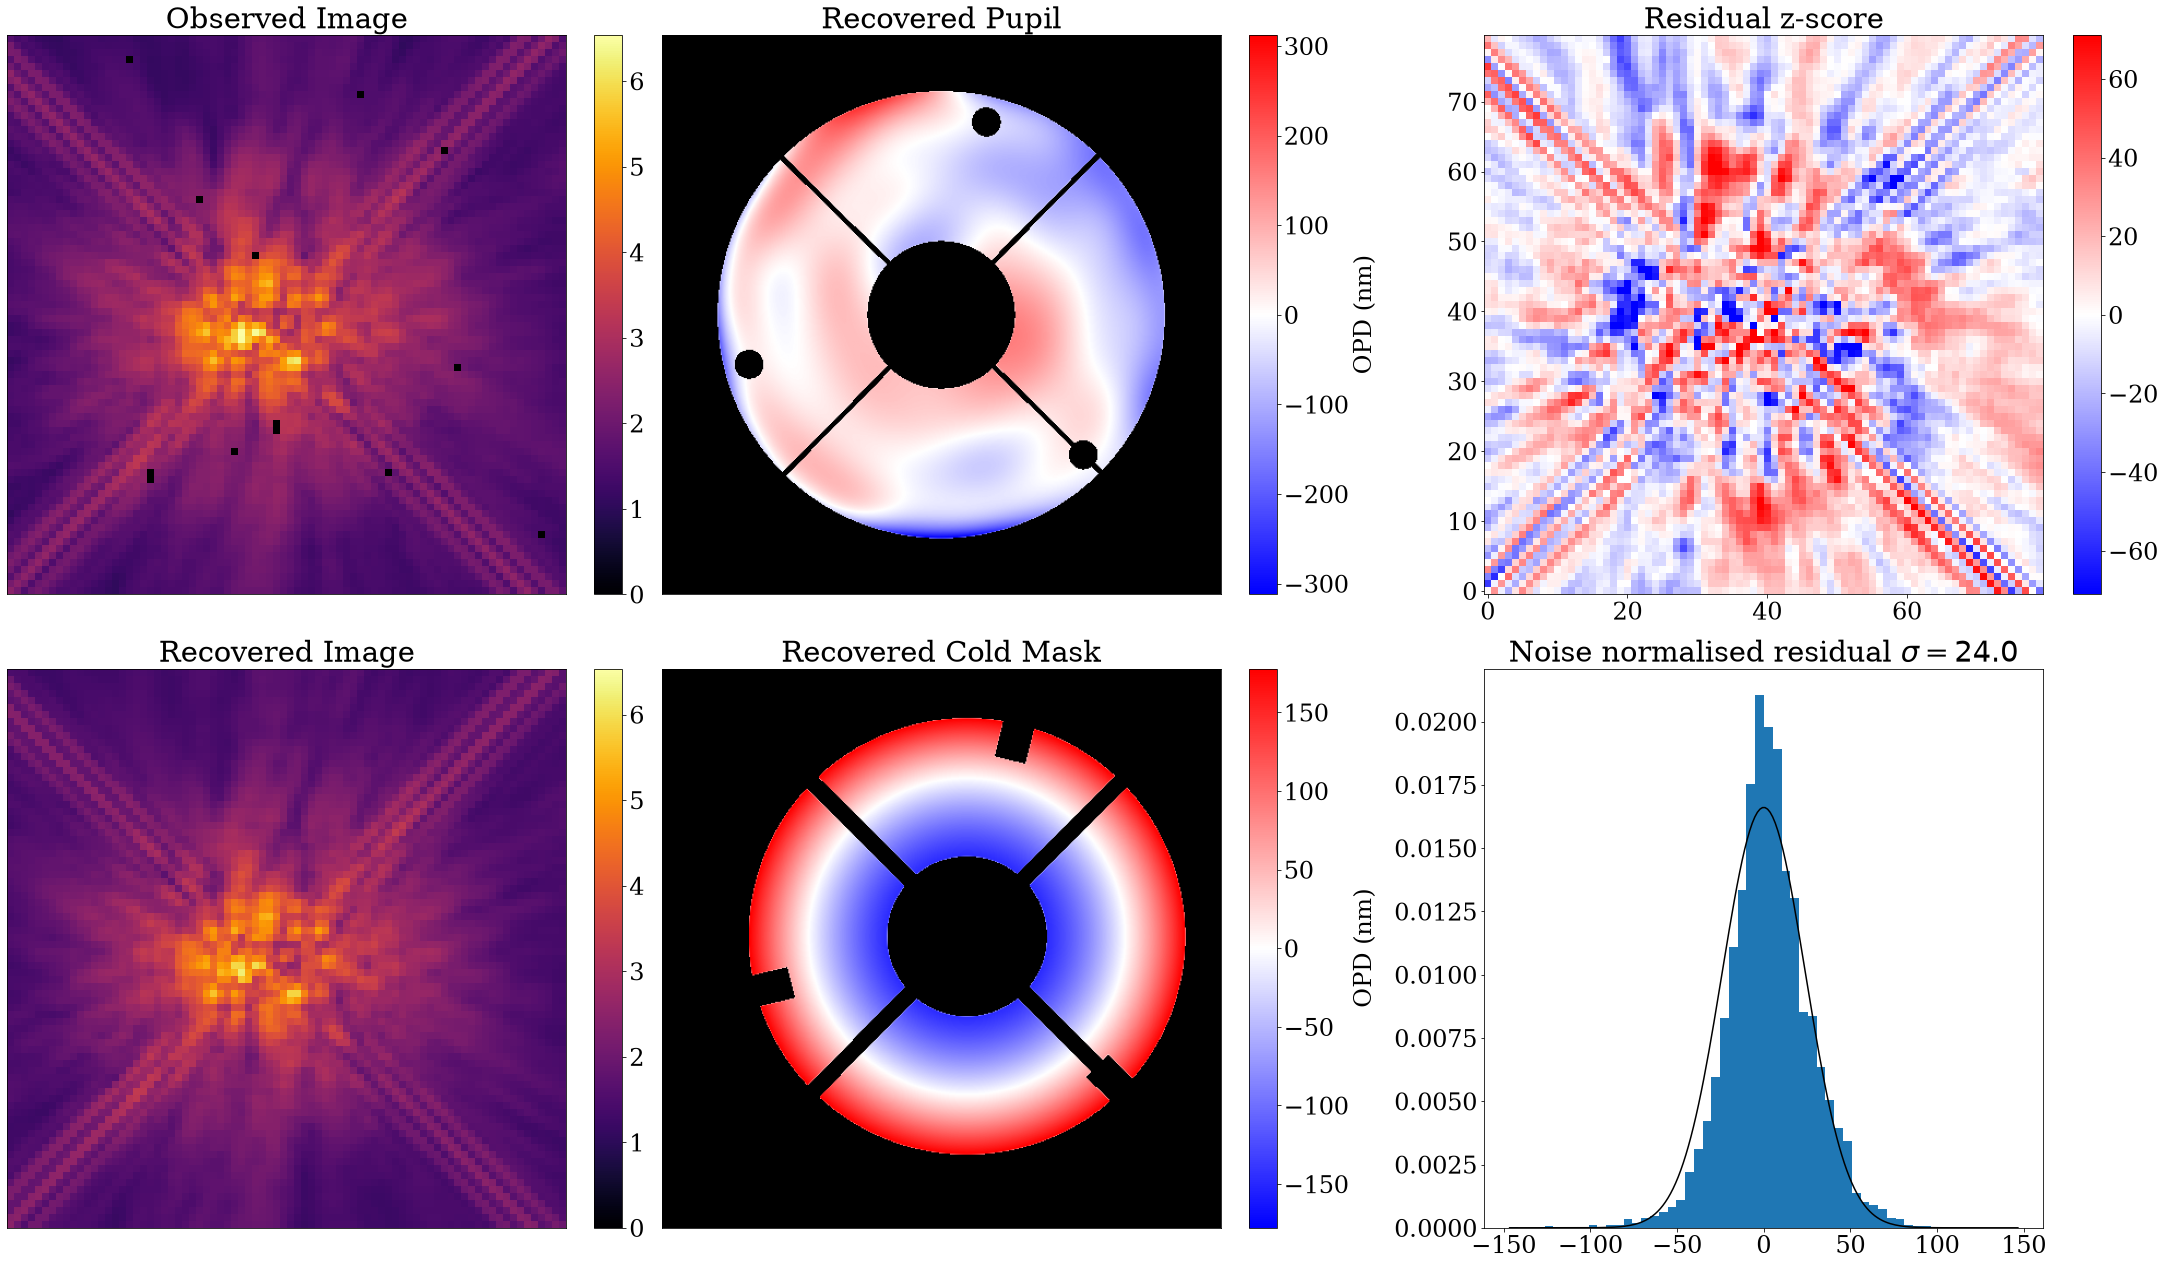

In [196]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, percentile=99)

In [197]:
params_history[-1]

{'bias': {'n4qs09akq': Array(0.8618923, dtype=float64)},
 'cold_mask_opd': {'global': Array([114.96728726], dtype=float64)},
 'cold_mask_rot': {'global': Array(-0.19923268, dtype=float64)},
 'cold_mask_shift': {'global': Array([13.84504691,  6.38520303], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.137211  , -0.12903807], dtype=float64)},
 'occulter_radius': Array(0.81630558, dtype=float64),
 'primary_low': {'n4qs09akq': Array([-26.09471856, -12.89405556, -12.61952825,  28.78299332,
         -28.38764535, -15.80545033,  15.60427713,  -7.82938316,
         -19.03996112,  -1.22474151, -13.92153304,   1.12991083,
           2.29537387,   1.78822769,  -5.15709796,  -7.38022617,
         -17.66737584,   3.52683206, -17.21713091,  -1.22229618,
          10.40985968,  11.80375847,  -6.51313589,  -9.76768285,
           7.82417684,   5.59626676,  15.72860058,  -2.5898633 ,
           7.4105771 ,   6.28198568], dtype=float64)},
 'primary_opd': {'global': Array([[  0.        ,   1.85

In [198]:
np.save("params.npy", params_history[-1])